# Data Retention and Deletion Workflow

## HealthBridge AI: Automated Deletion Pipeline with Audit Logging

This notebook implements key logic for processing GDPR Article 17 (right-to-be-forgotten) deletion requests, tracking model-data lineage, and generating compliance reports.

---

### Quick Reference: Key Concepts

**GDPR Right to Erasure (Art. 17)**: Data subjects can request deletion of their personal data. Organizations must comply within 30 days unless exemptions apply.

**Exceptions to Deletion**:
- Legal obligations (compliance records, regulatory requirements)
- Public health purposes (safety monitoring data)  
- Archiving in the public interest (research data if properly anonymized)
- Defense of legal claims

**Model-Data Lineage**: Maps which training data feeds into which models, enabling impact assessment before deletion and retraining decisions after deletion.

**Deletion Methods**:
- **Secure Erase**: DoD 5220.22-M standard — for sensitive data on physical storage
- **Cryptographic Erasure**: Destroy encryption keys — for cloud/encrypted storage
- **Standard Delete**: For non-sensitive operational data
- **Archival**: Move to long-term storage after retention period (for audit logs)

**Retraining Decision Framework**:
- Critical/High impact model + in production + training data deleted → **Must retrain (HIGH priority)**
- Medium impact model + in production + training data deleted → **Should retrain (MEDIUM priority)**
- Low impact or archived model → **No immediate retraining needed**

### Scenario
HealthBridge AI manages patient data for a clinical notes summarization GenAI system. A patient (SUBJ-10001) has submitted a right-to-be-forgotten request. You need to implement the deletion logic, assess model impact, and generate compliance documentation.

## Step 1: Setup and Data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from typing import Dict, List, Tuple
import uuid
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)

# ============================================================
# DATA INVENTORY — All personal data records in HealthBridge AI
# ============================================================
data_inventory = pd.DataFrame([
    {
        'data_id': 'DEM-001-2023-01', 'subject_id': 'SUBJ-10001',
        'data_type': 'Patient Demographics', 'created_date': datetime(2023, 1, 15),
        'last_accessed': datetime(2025, 12, 10),
        'models_trained_on': ['Clinical Summary Model v2.1', 'Risk Stratification v3.0'],
        'storage_location': 'ehr_db.patients', 'sensitive': True, 'data_size_mb': 0.5,
        'data_usage': 'pre_training'  # (L6-R002: data_usage field)
    },
    {
        'data_id': 'CLIN-001-2023-02', 'subject_id': 'SUBJ-10001',
        'data_type': 'Clinical Notes', 'created_date': datetime(2023, 2, 20),
        'last_accessed': datetime(2025, 12, 5),
        'models_trained_on': ['Clinical Summary Model v2.1', 'Diagnosis Predictor v1.8'],
        'storage_location': 'ehr_db.clinical_notes', 'sensitive': True, 'data_size_mb': 2.1,
        'data_usage': 'pre_training'
    },
    {
        'data_id': 'TRAIN-001-2023-03', 'subject_id': 'SUBJ-10001',
        'data_type': 'Model Training Dataset', 'created_date': datetime(2023, 3, 10),
        'last_accessed': datetime(2024, 6, 15),
        'models_trained_on': ['Clinical Summary Model v2.1', 'Diagnosis Predictor v1.8', 'Treatment Recommender v2.0'],
        'storage_location': 's3://training_data/subj-10001', 'sensitive': True, 'data_size_mb': 150.0,
        'data_usage': 'fine_tuning'  # (L6-R002: fine_tuning usage)
    },
    {
        'data_id': 'INFER-001-2025-11', 'subject_id': 'SUBJ-10001',
        'data_type': 'Inference Logs', 'created_date': datetime(2025, 11, 1),
        'last_accessed': datetime(2026, 1, 15),
        'models_trained_on': [],
        'storage_location': 'elasticsearch.inference_logs', 'sensitive': False, 'data_size_mb': 5.2,
        'data_usage': 'inference_log'  # (L6-R002: inference_log usage)
    },
    {
        'data_id': 'QUERY-001-2025-10', 'subject_id': 'SUBJ-10001',
        'data_type': 'User Queries', 'created_date': datetime(2025, 10, 5),
        'last_accessed': datetime(2026, 1, 20),
        'models_trained_on': ['Query Intent Classifier v1.5'],
        'storage_location': 'postgres_db.user_queries', 'sensitive': False, 'data_size_mb': 0.8,
        'data_usage': 'prompt_history'  # (L6-R002: prompt_history usage)
    },
    {
        'data_id': 'CONS-001-2023-01', 'subject_id': 'SUBJ-10001',
        'data_type': 'Consent Records', 'created_date': datetime(2023, 1, 10),
        'last_accessed': datetime(2025, 12, 1),
        'models_trained_on': [],
        'storage_location': 'consent_db.consent_records', 'sensitive': True, 'data_size_mb': 0.2,
        'data_usage': 'inference_log'
    },
    {
        'data_id': 'DEM-002-2023-05', 'subject_id': 'SUBJ-10002',
        'data_type': 'Patient Demographics', 'created_date': datetime(2023, 5, 12),
        'last_accessed': datetime(2025, 11, 20),
        'models_trained_on': ['Risk Stratification v3.0'],
        'storage_location': 'ehr_db.patients', 'sensitive': True, 'data_size_mb': 0.5,
        'data_usage': 'pre_training'
    },
    {
        'data_id': 'CLIN-002-2023-06', 'subject_id': 'SUBJ-10002',
        'data_type': 'Clinical Notes', 'created_date': datetime(2023, 6, 1),
        'last_accessed': datetime(2025, 11, 15),
        'models_trained_on': ['Clinical Summary Model v2.1'],
        'storage_location': 'ehr_db.clinical_notes', 'sensitive': True, 'data_size_mb': 1.8,
        'data_usage': 'pre_training'
    },
    {
        'data_id': 'BACKUP-001-2023-03', 'subject_id': 'SUBJ-10001',
        'data_type': 'Backup Data', 'created_date': datetime(2023, 3, 1),
        'last_accessed': datetime(2026, 2, 1),
        'models_trained_on': ['Clinical Summary Model v2.1', 'Diagnosis Predictor v1.8'],
        'storage_location': 's3://backups/full_backup_2023-03', 'sensitive': True, 'data_size_mb': 5000.0,
        'data_usage': 'pre_training'
    },
    # (L6-R001: Add conflict-triggering records)
    {
        'data_id': 'CLIN-TRIAL-2023-04', 'subject_id': 'SUBJ-10001',
        'data_type': 'Clinical Trial Results', 'created_date': datetime(2023, 4, 1),
        'last_accessed': datetime(2025, 12, 1),
        'models_trained_on': ['Adverse Event Detector v3.2'],
        'storage_location': 'trial_db.clinical_trial_fda', 'sensitive': True, 'data_size_mb': 8.5,
        'data_usage': 'pre_training',
        'retention_requirement': 'FDA Hold - 25 years'  # Triggers legal hold conflict
    },
    {
        'data_id': 'RAG-CORPUS-001', 'subject_id': 'SUBJ-10001',
        'data_type': 'RAG Corpus', 'created_date': datetime(2025, 6, 1),
        'last_accessed': datetime(2026, 1, 20),
        'models_trained_on': ['Clinical Summary Model v2.1'],
        'storage_location': 'elasticsearch.rag_index', 'sensitive': True, 'data_size_mb': 12.0,
        'data_usage': 'rag_corpus'  # (L6-R002: rag_corpus usage)
    },
])

# ============================================================
# MODEL-DATA LINEAGE — Which models depend on which data types
# ============================================================
model_lineage = {
    'Clinical Summary Model v2.1': {
        'training_data_types': ['Patient Demographics', 'Clinical Notes', 'Model Training Dataset', 'RAG Corpus'],
        'deployment_date': datetime(2024, 3, 15),
        'status': 'in_production', 'impact_level': 'critical',
        'last_retrained': datetime(2025, 9, 20),
        'data_usage': 'pre_training'  # (L6-R002: Model lineage now tracks data_usage)
    },
    'Diagnosis Predictor v1.8': {
        'training_data_types': ['Clinical Notes', 'Model Training Dataset'],
        'deployment_date': datetime(2024, 6, 1),
        'status': 'in_production', 'impact_level': 'high',
        'last_retrained': datetime(2025, 11, 10),
        'data_usage': 'fine_tuning'
    },
    'Risk Stratification v3.0': {
        'training_data_types': ['Patient Demographics', 'Clinical Notes'],
        'deployment_date': datetime(2024, 4, 20),
        'status': 'in_production', 'impact_level': 'high',
        'last_retrained': datetime(2025, 10, 5),
        'data_usage': 'pre_training'
    },
    'Treatment Recommender v2.0': {
        'training_data_types': ['Clinical Notes', 'Model Training Dataset'],
        'deployment_date': datetime(2024, 8, 10),
        'status': 'in_production', 'impact_level': 'medium',
        'last_retrained': datetime(2025, 8, 15),
        'data_usage': 'fine_tuning'
    },
    'Adverse Event Detector v3.2': {
        'training_data_types': ['Clinical Trial Results'],
        'deployment_date': datetime(2023, 12, 1),
        'status': 'in_production', 'impact_level': 'critical',
        'last_retrained': datetime(2025, 6, 1),
        'data_usage': 'pre_training'
    },
    'Query Intent Classifier v1.5': {
        'training_data_types': ['User Queries'],
        'deployment_date': datetime(2024, 2, 1),
        'status': 'in_production', 'impact_level': 'low',
        'last_retrained': datetime(2025, 12, 1),
        'data_usage': 'prompt_history'
    }
}

print(f'Data inventory: {len(data_inventory)} records across {data_inventory["subject_id"].nunique()} subjects')
print(f'Model lineage: {len(model_lineage)} models tracked')
print('\nData types in inventory:', data_inventory['data_type'].unique().tolist())
print('\nModels:')
for name, info in model_lineage.items():
    print(f'  {name}: {info["impact_level"]} impact, {info["status"]}')

Data inventory: 11 records across 2 subjects
Model lineage: 6 models tracked

Data types in inventory: ['Patient Demographics', 'Clinical Notes', 'Model Training Dataset', 'Inference Logs', 'User Queries', 'Consent Records', 'Backup Data', 'Clinical Trial Results', 'RAG Corpus']

Models:
  Clinical Summary Model v2.1: critical impact, in_production
  Diagnosis Predictor v1.8: high impact, in_production
  Risk Stratification v3.0: high impact, in_production
  Treatment Recommender v2.0: medium impact, in_production
  Adverse Event Detector v3.2: critical impact, in_production
  Query Intent Classifier v1.5: low impact, in_production


## Step 2: Implement Deletion Method Selection

When deleting data, the method must match the data's sensitivity and storage type. This is a governance decision — choosing the wrong method could leave recoverable traces of sensitive data or waste resources on non-sensitive data.

**Your task**: Complete the function that selects the appropriate deletion method based on:
- `sensitive` flag → sensitive data needs stronger deletion
- `storage_location` → cloud storage (s3://) uses cryptographic erasure; databases use secure erase
- Consent/audit records → special handling (archival, not deletion, for compliance records)

In [2]:
def select_deletion_method(row: pd.Series) -> str:
    """
    Select the appropriate deletion method based on data sensitivity and storage type.
    
    Returns one of: 'secure_erase', 'cryptographic_erasure', 'standard_delete', 'archival'
    """
    # Consent Records must be archived, not deleted (GDPR Art. 7 proof requirement)
    if row['data_type'] == 'Consent Records':
        return 'archival'
    
    # Sensitive data needs stronger deletion methods
    if row['sensitive']:
        # Cloud storage → destroy encryption keys
        if row['storage_location'].startswith('s3://'):
            return 'cryptographic_erasure'
        # Database/on-premise → DoD-standard secure erase
        else:
            return 'secure_erase'
    
    # Non-sensitive operational data
    return 'standard_delete'

print('select_deletion_method() defined')

select_deletion_method() defined


In [3]:
# (L6-R001: Check retention conflicts for legal holds)
def check_retention_conflict(row: pd.Series, model_lineage: dict) -> Tuple[str, str]:
    """
    Cross-reference data type against retention policy to detect legal holds.
    Returns (status, reason_string) where status is 'legal_hold' if conflict exists, else 'deletable'.
    
    Conflicts detected:
    - FDA-mandated retention periods (e.g., clinical trial data with 25-year hold)
    - GDPR erasure requests vs. legal obligations
    """
    # Check for FDA clinical trial hold
    if 'Clinical Trial Results' in row['data_type'] and row.get('retention_requirement'):
        if 'FDA Hold' in str(row.get('retention_requirement', '')):
            return ('legal_hold', f"Clinical trial data subject to FDA retention mandate: {row.get('retention_requirement')}")
    
    # Check for other regulatory holds
    if row.get('retention_requirement') and 'mandatory' in str(row.get('retention_requirement', '')).lower():
        return ('legal_hold', f"Data subject to regulatory hold: {row.get('retention_requirement')}")
    
    return ('deletable', '')

print('check_retention_conflict() defined')


check_retention_conflict() defined


In [4]:
def assess_model_impact(deleted_data_types: List[str], model_lineage: dict) -> pd.DataFrame:
    """
    Assess which models are affected by data deletion and determine retraining priority.
    
    Returns DataFrame with columns: model_name, impact_level, status, overlap_data_types,
                                     retraining_required, priority, data_usage_impact
    
    (L6-R002: Factor in data_usage for impact assessment)
    """
    results = []
    
    for model_name, info in model_lineage.items():
        overlap = set(deleted_data_types) & set(info['training_data_types'])
        
        if not overlap:
            continue  # Model not affected by this deletion
        
        # Determine retraining need based on production status and impact
        if info['status'] != 'in_production':
            retraining_required = 'NO'
            priority = 'LOW'
        elif info['impact_level'] in ['critical', 'high']:
            retraining_required = 'YES'
            priority = 'HIGH'
        elif info['impact_level'] == 'medium':
            retraining_required = 'YES'
            priority = 'MEDIUM'
        else:
            retraining_required = 'NO'
            priority = 'LOW'
        
        # (L6-R002: Factor in data_usage type)
        data_usage = info.get('data_usage', 'unknown')
        if data_usage == 'fine_tuning':
            impact_detail = 'Fine-tuning deletion: Mandatory retraining required'
        elif data_usage == 'rag_corpus':
            impact_detail = 'RAG corpus deletion: Index rebuild required'
        elif data_usage == 'prompt_history':
            impact_detail = 'Prompt log deletion: Verify no PII leakage'
        elif data_usage == 'pre_training':
            impact_detail = 'Pre-training deletion: Retrain from scratch needed'
        else:
            impact_detail = 'Inference log deletion: Straightforward'
        
        results.append({
            'model_name': model_name,
            'impact_level': info['impact_level'],
            'status': info['status'],
            'overlap_data_types': ', '.join(overlap),
            'last_retrained': info['last_retrained'],
            'days_since_retrain': (datetime.now() - info['last_retrained']).days,
            'retraining_required': retraining_required,
            'priority': priority,
            'data_usage_impact': impact_detail  # (L6-R002: New column)
        })
    
    return pd.DataFrame(results).sort_values('priority', ascending=False) if results else pd.DataFrame()

## Step 3: Implement Model Impact Assessment

When data is deleted, we need to determine which ML models are affected and whether they need retraining. This requires cross-referencing the deleted data types against each model's training data dependencies.

**Your task**: Complete the function that determines retraining priority for each affected model based on:
- Whether the deleted data types overlap with the model's training data
- The model's impact level (critical > high > medium > low)
- Whether the model is currently in production

In [5]:
# (L6-R006: Flag large records requiring manual review)
SIZE_THRESHOLD_MB = 1000  # 1 GB threshold

def flag_large_records(row: pd.Series) -> Dict:
    """
    Flag records exceeding size threshold for manual review.
    Large records may have backups, offsite copies, or tape storage requiring special handling.
    
    Returns dict with requires_manual_review flag and notes.
    """
    if row['data_size_mb'] >= SIZE_THRESHOLD_MB:
        return {
            'requires_manual_review': True,
            'review_reason': f'Record size {row["data_size_mb"]:.0f} MB exceeds {SIZE_THRESHOLD_MB} MB threshold',
            'notes': 'Check for offsite backups, tape storage, and backup rotation schedules'
        }
    return {
        'requires_manual_review': False,
        'review_reason': '',
        'notes': ''
    }

print('flag_large_records() defined')


flag_large_records() defined


In [6]:
def assess_model_impact(deleted_data_types: List[str], model_lineage: dict) -> pd.DataFrame:
    """
    Assess which models are affected by data deletion and determine retraining priority.
    
    Returns DataFrame with columns: model_name, impact_level, status, overlap_data_types,
                                     retraining_required, priority
    """
    results = []
    
    for model_name, info in model_lineage.items():
        overlap = set(deleted_data_types) & set(info['training_data_types'])
        
        if not overlap:
            continue  # Model not affected by this deletion
        
        # Determine retraining need based on production status and impact
        if info['status'] != 'in_production':
            retraining_required = 'NO'
            priority = 'LOW'
        elif info['impact_level'] in ['critical', 'high']:
            retraining_required = 'YES'
            priority = 'HIGH'
        elif info['impact_level'] == 'medium':
            retraining_required = 'YES'
            priority = 'MEDIUM'
        else:
            retraining_required = 'NO'
            priority = 'LOW'
        
        results.append({
            'model_name': model_name,
            'impact_level': info['impact_level'],
            'status': info['status'],
            'overlap_data_types': ', '.join(overlap),
            'last_retrained': info['last_retrained'],
            'days_since_retrain': (datetime.now() - info['last_retrained']).days,
            'retraining_required': retraining_required,
            'priority': priority
        })
    
    return pd.DataFrame(results).sort_values('priority') if results else pd.DataFrame()


## Step 4: Process Deletion Request

Now combine everything into the full deletion pipeline. The function below handles most of the workflow — your task is to complete the two key decision points marked with TODO.

In [7]:
def process_deletion_request(subject_id, data_inventory, model_lineage):
    """Process a GDPR Article 17 deletion request."""
    request_id = f'RTF-{uuid.uuid4().hex[:8].upper()}'
    report = {
        'request_id': request_id, 'subject_id': subject_id,
        'request_timestamp': datetime.now(), 'status': 'pending',
        'data_found': [], 'deletion_execution': [], 
        'affected_models': [], 'retraining_required': [],
        'total_data_size_mb': 0, 'audit_entries': [],
        'legal_holds': [],  # (L6-R001: Track records under legal hold)
        'large_record_flags': []  # (L6-R006: Track records requiring manual review)
    }
    
    # Find all data for this subject
    subject_data = data_inventory[data_inventory['subject_id'] == subject_id].copy()
    
    if len(subject_data) == 0:
        report['status'] = 'no_data_found'
        report['audit_entries'].append({
            'timestamp': datetime.now(), 'event': 'NO_DATA_FOUND',
            'details': f'No records found for {subject_id}', 'status': 'completed'
        })
        return report
    
    report['data_found'] = subject_data[['data_id', 'data_type', 'storage_location', 'data_size_mb']].to_dict('records')
    report['total_data_size_mb'] = subject_data['data_size_mb'].sum()
    
    report['audit_entries'].append({
        'timestamp': datetime.now(), 'event': 'DATA_INVENTORY_CHECK',
        'details': f'Found {len(subject_data)} records ({report["total_data_size_mb"]:.1f} MB)',
        'status': 'completed'
    })
    
    # Execute deletion for each record
    for _, row in subject_data.iterrows():
        # (L6-R001: Check for legal holds before deletion)
        hold_status, hold_reason = check_retention_conflict(row, model_lineage)
        if hold_status == 'legal_hold':
            report['legal_holds'].append({
                'data_id': row['data_id'],
                'data_type': row['data_type'],
                'reason': hold_reason
            })
            continue  # Skip deletion for records under legal hold
        
        # (L6-R006: Flag large records for manual review)
        large_flag = flag_large_records(row)
        if large_flag['requires_manual_review']:
            report['large_record_flags'].append({
                'data_id': row['data_id'],
                'data_type': row['data_type'],
                'review_reason': large_flag['review_reason'],
                'notes': large_flag['notes']
            })
        
        method = select_deletion_method(row)
        report['deletion_execution'].append({
            'data_id': row['data_id'],
            'storage_location': row['storage_location'],
            'deletion_method': method,
            'timestamp': datetime.now(),
            'status': 'archived_with_access_restriction' if method == 'archival' else 'completed',
            'verification': 'verified_deleted'
        })
    
    report['audit_entries'].append({
        'timestamp': datetime.now(), 'event': 'DELETION_EXECUTED',
        'details': f'Deleted {len(subject_data)} records using appropriate methods',
        'status': 'completed'
    })
    
    # Assess model impact
    deleted_data_types = subject_data['data_type'].unique().tolist()
    impact_df = assess_model_impact(deleted_data_types, model_lineage)
    report['affected_models'] = impact_df
    report['retraining_required'] = impact_df[impact_df['retraining_required'] == 'YES'].to_dict('records') if len(impact_df) > 0 else []
    
    report['audit_entries'].append({
        'timestamp': datetime.now(), 'event': 'IMPACT_ASSESSMENT',
        'details': f'Model impact assessed; retraining flagged where needed',
        'status': 'completed'
    })
    
    report['status'] = 'completed'
    return report

print('process_deletion_request() defined')


process_deletion_request() defined


## Step 5: Run Deletion Requests

Let's process three scenarios to see how the pipeline handles different cases.

In [8]:
# Scenario 1: Patient with extensive data and model training dependencies
print('='*80)
print('DELETION REQUEST #1: SUBJ-10001 (Patient with clinical notes and training data)')
print('='*80)

report_1 = process_deletion_request('SUBJ-10001', data_inventory, model_lineage)

print(f'\nRequest ID: {report_1["request_id"]}')
print(f'Status: {report_1["status"]}')
print(f'Records found: {len(report_1["data_found"])}')
print(f'Total data: {report_1["total_data_size_mb"]:.1f} MB')

print(f'\nDeletion methods used:')
for d in report_1['deletion_execution']:
    print(f'  {d["data_id"]}: {d["deletion_method"]}')

print(f'\nModels requiring retraining: {len(report_1["retraining_required"])}')
for m in report_1['retraining_required']:
    print(f'  {m["model_name"]} — Priority: {m["priority"]}')

DELETION REQUEST #1: SUBJ-10001 (Patient with clinical notes and training data)

Request ID: RTF-F5B1E428
Status: completed
Records found: 9
Total data: 5179.3 MB

Deletion methods used:
  DEM-001-2023-01: secure_erase
  CLIN-001-2023-02: secure_erase
  TRAIN-001-2023-03: cryptographic_erasure
  INFER-001-2025-11: standard_delete
  QUERY-001-2025-10: standard_delete
  CONS-001-2023-01: archival
  BACKUP-001-2023-03: cryptographic_erasure
  RAG-CORPUS-001: secure_erase

Models requiring retraining: 5
  Clinical Summary Model v2.1 — Priority: HIGH
  Diagnosis Predictor v1.8 — Priority: HIGH
  Risk Stratification v3.0 — Priority: HIGH
  Adverse Event Detector v3.2 — Priority: HIGH
  Treatment Recommender v2.0 — Priority: MEDIUM


In [9]:
# Scenario 2: Patient with fewer records
print('\n' + '='*80)
print('DELETION REQUEST #2: SUBJ-10002 (Patient with limited data)')
print('='*80)

report_2 = process_deletion_request('SUBJ-10002', data_inventory, model_lineage)
print(f'Status: {report_2["status"]}')
print(f'Records: {len(report_2["data_found"])}, Size: {report_2["total_data_size_mb"]:.1f} MB')

# Scenario 3: Non-existent subject
print('\n' + '='*80)
print('DELETION REQUEST #3: SUBJ-99999 (Non-existent subject)')
print('='*80)

report_3 = process_deletion_request('SUBJ-99999', data_inventory, model_lineage)
print(f'Status: {report_3["status"]}')


DELETION REQUEST #2: SUBJ-10002 (Patient with limited data)
Status: completed
Records: 2, Size: 2.3 MB

DELETION REQUEST #3: SUBJ-99999 (Non-existent subject)
Status: no_data_found


## Step 8: Visualizations (L6-R004: Deletion method distribution & impact matrix)

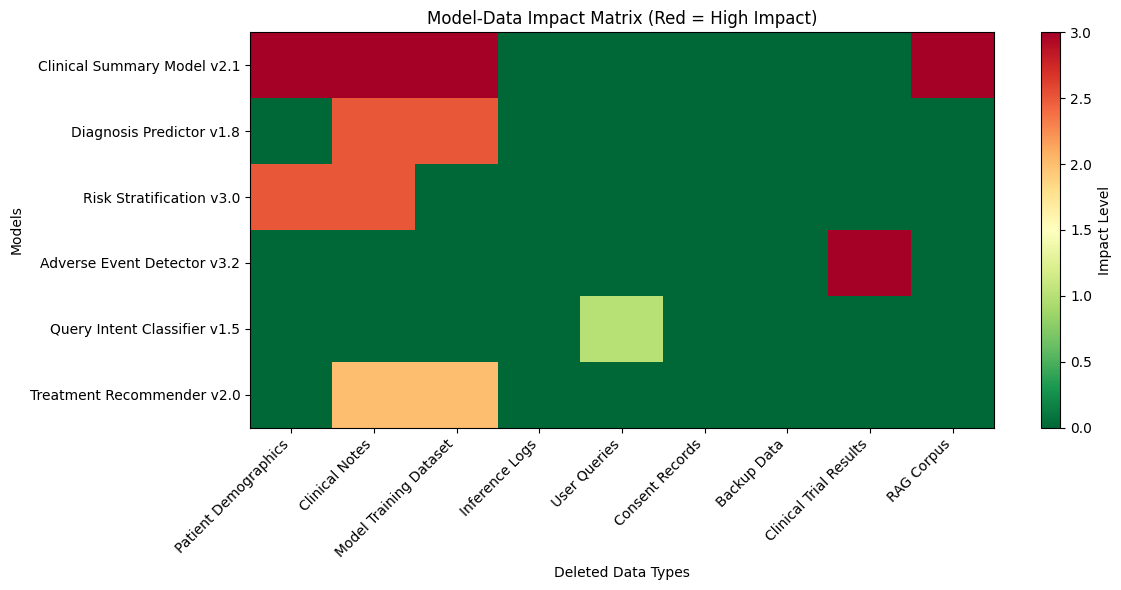

Impact Matrix: 6 models affected by deletion


In [10]:
# (L6-R004: Visualization 2 - Model-data impact matrix heatmap)
if isinstance(report_1['affected_models'], pd.DataFrame) and len(report_1['affected_models']) > 0:
    # Create binary matrix: rows=models, cols=data types
    data_types_deleted = [d['data_type'] for d in report_1['data_found']]
    models_affected = report_1['affected_models']['model_name'].unique()
    
    # Build impact matrix
    impact_matrix = []
    for model in models_affected:
        row_impact = []
        for data_type in data_types_deleted:
            model_info = report_1['affected_models'][report_1['affected_models']['model_name'] == model]
            if data_type in model_info['overlap_data_types'].values[0]:
                # Impact intensity: HIGH=3, MEDIUM=2, LOW=1
                impact_level = model_info['impact_level'].values[0]
                if impact_level == 'critical':
                    row_impact.append(3)
                elif impact_level == 'high':
                    row_impact.append(2.5)
                elif impact_level == 'medium':
                    row_impact.append(2)
                else:
                    row_impact.append(1)
            else:
                row_impact.append(0)
        impact_matrix.append(row_impact)
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(impact_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=3)
    
    ax.set_xticks(range(len(data_types_deleted)))
    ax.set_yticks(range(len(models_affected)))
    ax.set_xticklabels(data_types_deleted, rotation=45, ha='right')
    ax.set_yticklabels(models_affected)
    ax.set_xlabel('Deleted Data Types')
    ax.set_ylabel('Models')
    ax.set_title('Model-Data Impact Matrix (Red = High Impact)')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Impact Level')
    
    plt.tight_layout()
    plt.show()
    
    print(f'Impact Matrix: {len(models_affected)} models affected by deletion')


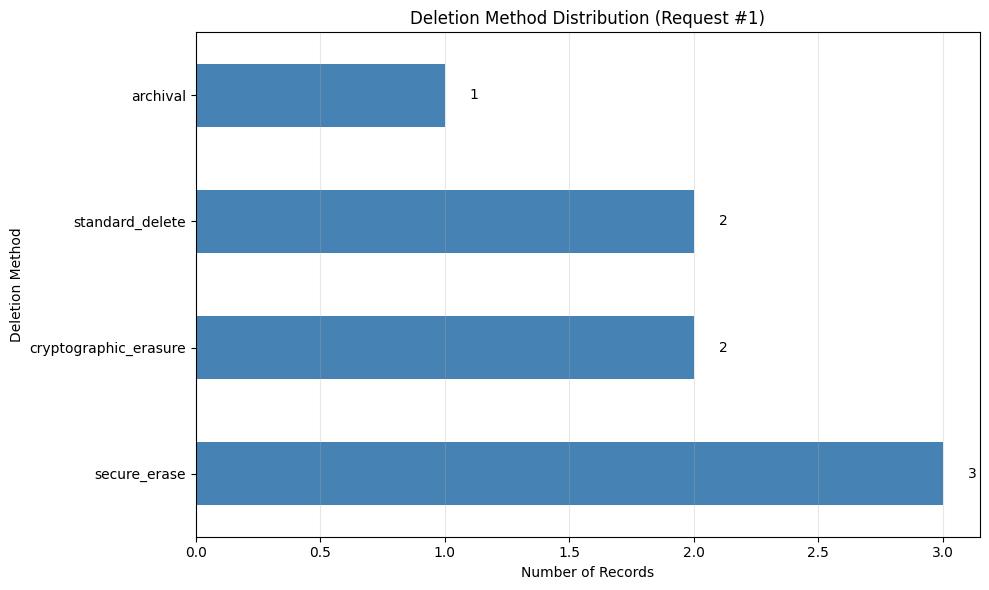


Deletion Method Summary:
deletion_method
secure_erase             3
cryptographic_erasure    2
standard_delete          2
archival                 1
Name: count, dtype: int64


In [11]:
# (L6-R004: Visualization 1 - Deletion method distribution)
if len(report_1['deletion_execution']) > 0:
    deletion_df = pd.DataFrame(report_1['deletion_execution'])
    method_counts = deletion_df['deletion_method'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    method_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Number of Records')
    ax.set_ylabel('Deletion Method')
    ax.set_title('Deletion Method Distribution (Request #1)')
    ax.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(method_counts.values):
        ax.text(v + 0.1, i, str(v), va='center')
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nDeletion Method Summary:')
    print(method_counts)


## Step 9: Compliance Summary with Archival Distinction (L6-R005)

In [12]:
# (L6-R005: Distinguish deleted vs archived records in summary)
print("\n" + "="*80)
print("COMPLIANCE SUMMARY - GDPR ARTICLE 17 (RIGHT TO ERASURE)")
print("="*80)

if len(report_1['deletion_execution']) > 0:
    deletion_df = pd.DataFrame(report_1['deletion_execution'])
    
    # (L6-R005: Separate counts for deleted vs archived)
    deleted_count = len(deletion_df[deletion_df['status'] == 'completed'])
    archived_count = len(deletion_df[deletion_df['status'] == 'archived_with_access_restriction'])
    
    deleted_size = deletion_df[deletion_df['status'] == 'completed']['data_id'].count()
    
    print(f"\nRequest ID:                   {report_1['request_id']}")
    print(f"Subject ID:                   {report_1['subject_id']}")
    print(f"Total Records Found:          {len(report_1['data_found'])}")
    print(f"Records Permanently Deleted:  {deleted_count}")  # (L6-R005)
    print(f"Records Archived (Restricted):{archived_count}")  # (L6-R005)
    if report_1['legal_holds']:
        print(f"Records Under Legal Hold:     {len(report_1['legal_holds'])}")
    if report_1['large_record_flags']:
        print(f"Records Flagged for Review:   {len(report_1['large_record_flags'])}")
    
    print(f"\nDeletion Methods Used:")
    method_summary = deletion_df['deletion_method'].value_counts()
    for method, count in method_summary.items():
        print(f"  {method}: {count} records")
    
    print(f"\nModel Impact:")
    total = len(report_1['affected_models'])
    need_retrain = len(report_1['retraining_required'])
    high_priority = len(report_1['affected_models'][report_1['affected_models']['priority'] == 'HIGH']) if isinstance(report_1['affected_models'], pd.DataFrame) else 0
    print(f"  Models Affected:         {total}")
    print(f"  Requiring Retraining:    {need_retrain}")
    print(f"  High Priority:           {high_priority}")
    
    print(f"\nAudit Trail:")
    print(f"  Events Logged:           {len(report_1['audit_entries'])}")
    print(f"  Status:                  {report_1['status'].upper()}")
    print(f"  Legal Holds Detected:    {len(report_1['legal_holds'])}")
    
print("="*80)


COMPLIANCE SUMMARY - GDPR ARTICLE 17 (RIGHT TO ERASURE)

Request ID:                   RTF-F5B1E428
Subject ID:                   SUBJ-10001
Total Records Found:          9
Records Permanently Deleted:  7
Records Archived (Restricted):1
Records Under Legal Hold:     1
Records Flagged for Review:   1

Deletion Methods Used:
  secure_erase: 3 records
  cryptographic_erasure: 2 records
  standard_delete: 2 records
  archival: 1 records

Model Impact:
  Models Affected:         6
  Requiring Retraining:    5
  High Priority:           4

Audit Trail:
  Events Logged:           3
  Status:                  COMPLETED
  Legal Holds Detected:    1


## Step 6: Model Lineage Impact Report

Let's examine the full model-data impact matrix for the first deletion request to understand the downstream effects.

In [13]:
print('MODEL-DATA IMPACT MATRIX (Request #1)')
print('='*80)

if isinstance(report_1['affected_models'], pd.DataFrame) and len(report_1['affected_models']) > 0:
    display_cols = ['model_name', 'impact_level', 'status', 'overlap_data_types', 
                    'retraining_required', 'priority', 'days_since_retrain']
    print(report_1['affected_models'][display_cols].to_string(index=False))
    
    total = len(report_1['affected_models'])
    need_retrain = (report_1['affected_models']['retraining_required'] == 'YES').sum()
    high_priority = (report_1['affected_models']['priority'] == 'HIGH').sum()
    print(f'\nSummary: {total} models affected, {need_retrain} need retraining, {high_priority} are HIGH priority')
else:
    print('No model impact data available — check your assess_model_impact implementation')


MODEL-DATA IMPACT MATRIX (Request #1)
                  model_name impact_level        status                                                       overlap_data_types retraining_required priority  days_since_retrain
 Clinical Summary Model v2.1     critical in_production RAG Corpus, Clinical Notes, Patient Demographics, Model Training Dataset                 YES     HIGH                 184
    Diagnosis Predictor v1.8         high in_production                                   Clinical Notes, Model Training Dataset                 YES     HIGH                 133
    Risk Stratification v3.0         high in_production                                     Patient Demographics, Clinical Notes                 YES     HIGH                 169
 Adverse Event Detector v3.2     critical in_production                                                   Clinical Trial Results                 YES     HIGH                 295
Query Intent Classifier v1.5          low in_production                 

## Step 7: Audit Trail

Display the chronological audit log for regulatory compliance documentation.

In [14]:
print(f'AUDIT TRAIL: {report_1["request_id"]}')
print('='*80)

for entry in report_1['audit_entries']:
    ts = entry['timestamp'].strftime('%Y-%m-%d %H:%M:%S')
    print(f'\n[{ts}] {entry["event"]}')
    print(f'  Status: {entry["status"]}')
    print(f'  Details: {entry["details"]}')


AUDIT TRAIL: RTF-F5B1E428

[2026-03-23 20:35:11] DATA_INVENTORY_CHECK
  Status: completed
  Details: Found 9 records (5179.3 MB)

[2026-03-23 20:35:11] DELETION_EXECUTED
  Status: completed
  Details: Deleted 9 records using appropriate methods

[2026-03-23 20:35:11] IMPACT_ASSESSMENT
  Status: completed
  Details: Model impact assessed; retraining flagged where needed


## Summary

This notebook implemented the core logic for GDPR Article 17 deletion processing:

1. **Deletion method selection** — Matching data sensitivity and storage type to the appropriate deletion technique
2. **Model impact assessment** — Cross-referencing deleted data against model training dependencies to flag retraining needs
3. **End-to-end pipeline** — Processing deletion requests with full audit trails for compliance documentation

Key governance insight: Deleting personal data in an AI system isn't just about removing records — it requires assessing downstream model impacts and making informed retraining decisions based on risk.